<a href="https://colab.research.google.com/github/chenliu-DH/Gemini-2.5-flash_-SFT-DPO_experiment/blob/new-data_split-2/gemini%202.5%20experiment_new-data_split2_new_with%20misalignment%20data%20and%20temperature0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Supervised Fine Tuning & DPO with Gemini 2.5 Flash**
  reference:https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini-supervised-tuning

  data:https://storage.googleapis.com/dh-search-science-shared/roman/qc-train-data/Thomas/export_145692_project-145692-at-2025-06-03-09-50-c307134e.json

<h1 style="font-size: 40px; font-weight: bold; color: #1a73e8;">
  Project Overview: E-commerce Search Relevance Fine-Tuning
</h1>

This project demonstrates an advanced workflow for optimizing **Gemini 2.5 Flash** to perform high-accuracy product relevance labeling. By leveraging the **Amazon ESCI (Exact, Substitute, Complement, Irrelevant)** scale, we transform raw search query data into a structured classification system for e-commerce search engines.

### **Key Components**
* **Model Architecture**: Utilizes **Gemini 2.5 Flash** for efficient, high-speed inference and labeling.
* **Dataset Integration**: Processes large-scale JSON data hosted on **Google Cloud Storage (GCS)**, featuring localized product names and multi-language attributes.
* **Two-Stage Optimization**:
    * **Stage 1: Supervised Fine-Tuning (SFT)** to teach the model the base ESCI definitions and formatting requirements.
    * **Stage 2: Direct Preference Optimization (DPO)** to refine the model's decision-making on "hard negatives" and cross-category errors.
* **Automated Evaluation**: Includes a comprehensive error analysis pipeline that calculates **Score Differences (Distance)** to quantify the severity of misclassifications.

<h1 style="font-size: 36px; font-weight: bold; color: #34a853;">
  Technical Objectives
</h1>

The primary goal of this implementation is to surpass baseline model performance in complex search scenarios by aligning AI outputs with expert human annotations through a rigorous feedback loop.

### **Strategic Goals**
1.  **High-Precision Labeling**: Achieve over 90% accuracy across the four ESCI grades, specifically reducing "fatal" errors such as labeling an **Exact** match as **Irrelevant**.
2.  **Cross-Lingual Consistency**: Ensure the model maintains high labeling quality across different languages (e.g., Arabic, English) by utilizing the `language` attribute during training and evaluation.
3.  **Instruction Adherence**: Enforce strict output constraints (Single Word Labels) without the need for additional post-processing or regex cleaning.
4.  **DPO Preference Alignment**:
    * Identify "Hard Negatives" from the SFT training set where the model's confidence is misplaced.
    * Construct a **Chosen/Rejected** dataset based on the **Score Difference (score_diff)** metric to penalize high-distance errors more heavily.
5.  **Scalable Inference**: Implement **Vertex AI Batch Prediction** to handle thousands of queries asynchronously, optimizing both cost and processing time.

## Getting Started

### Install Gen AI SDK and other required packages

The new Google Gen AI SDK provides a unified interface to Gemini through both the Gemini Developer API and the Gemini API on Vertex AI. With a few exceptions, code that runs on one platform will run on both. This means that you can prototype an application using the Developer API and then migrate the application to Vertex AI without rewriting your code.


In [1]:
%pip install --upgrade --user --quiet google-genai google-cloud-aiplatform rouge_score plotly jsonlines

## Step0: Authenticate your notebook environment (Colab only)

If you are running this notebook on Google Colab, run the cell below to authenticate your environment.

In [2]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

- If you are running this notebook in a local development environment:
  - Install the [Google Cloud SDK](https://cloud.google.com/sdk).
  - Obtain authentication credentials. Create local credentials by running the following command and following the oauth2 flow (read more about the command [here](https://cloud.google.com/sdk/gcloud/reference/beta/auth/application-default/login)):

    ```bash
    gcloud auth application-default login
    ```

## Step1: Import Libraries

In [3]:
import time

# For data handling.
import jsonlines
import pandas as pd

# For visualization.
import plotly.graph_objects as go

# For fine tuning Gemini model.
import vertexai
from google import genai

# For extracting vertex experiment details.
from google.cloud import aiplatform
from google.cloud.aiplatform.metadata import context
from google.cloud.aiplatform.metadata import utils as metadata_utils
from google.genai import types
from plotly.subplots import make_subplots

# For evaluation metric computation.
from rouge_score import rouge_scorer
from tqdm import tqdm
from IPython.display import Markdown, display
from datasets import load_dataset

## Step2: Set Google Cloud project information and initialize Vertex AI and Gen AI SDK

To get started using Vertex AI, you must have an existing Google Cloud project and [enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).


In [4]:
PROJECT_ID = "search-science-shared-7335"
REGION = "us-central1"

In [5]:
vertexai.init(project=PROJECT_ID, location=REGION)

client = genai.Client(vertexai=True, project=PROJECT_ID, location=REGION)

## Step3: Create Dataset in correct format

The dataset used to tune a foundation model needs to include examples that align with the task that you want the model to perform. Structure your training dataset in a text-to-text format. Each record, or row, in the dataset contains the input text (also referred to as the prompt) which is paired with its expected output from the model. Supervised tuning uses the dataset to teach the model to mimic a behavior, or task, you need by giving it hundreds of examples that illustrate that behavior.

Your dataset size depends on the task, and follows the recommendation mentioned in the `Overview` section. The more examples you provide in your dataset, the better the results.

### Dataset format

Training data should be structured within a JSONL file located at a Google Cloud Storage (GCS) URI. Each line (or row) of the JSONL file must adhere to a specific schema: It should contain a `contents` array, with objects inside defining a `role` (either "user" for user input or "model" for model output) and `parts`, containing the input data. For example, a valid data row would look like this:


```json
{
  "contents": [
    {
      "role": "user", # This indicates input content
      "parts": [
        {
          "text": "How are you?"
        }
      ]
    },
    {
      "role": "model", # This indicates target content
      "parts": [ # text only
        {
          "text": "I am good, thank you!"
        }
      ]
    }
  ] #  ... repeat "user", "model" for multi turns.
}
```

Refer to the public [documentation](https://cloud.google.com/vertex-ai/generative-ai/docs/models/gemini-supervised-tuning-prepare#about-datasets) for more details.

To run a tuning job, you need to upload one or more datasets to a Cloud Storage bucket. You can either create a new Cloud Storage bucket or use an existing one to store dataset files. The region of the bucket doesn't matter, but we recommend that you use a bucket that's in the same Google Cloud project where you plan to tune your model.

Step3: transform the format

In [6]:
import json
import pandas as pd
import numpy as np

def process_and_export_relevance_data(source_path, agreement_threshold, file_prefix, user_content_template, split_strategy=1, merge_misalignment_to_train=0):
    """
    Reads, cleans, filters, and exports search relevance data with specific query downsampling.
    Also extracts and resolves low-agreement data (misalignment) using majority voting.

    Args:
        source_path (str): The file path of the source JSON.
        agreement_threshold (int): The threshold for agreement filtering (e.g., 100).
        file_prefix (str): The prefix for output files (e.g., "sft_v1").
        user_content_template (str): The user prompt template, must include {sq} and {pnl} placeholders.
        split_strategy (int):
            1 for Random row-level split (70/15/15).
            2 for Query-level split (70/15/15 on unique queries).
        merge_misalignment_to_train (int):
            If 1, the resolved misalignment data will be appended to the training data.
            If 0 (default), it will remain completely separate.

    Returns:
        tuple: (train_df, val_df, test_df, misalignment_df) if successful, otherwise (None, None, None, None).
    """

    print(f"Reading data from: {source_path}")
    RANDOM_STATE = 42

    # ==========================================
    # 1. Data Loading
    # ==========================================
    try:
        df_raw = pd.read_json(source_path)
        records = df_raw.to_dict(orient='records')
    except Exception as e:
        print(f"Pandas read failed, attempting manual load: {e}")
        records = []

    # ==========================================
    # 2. Data Cleaning and Field Extraction
    # ==========================================
    extracted_rows = []
    if records:
        for item in records:
            item_data = item.get('data', {})

            # Extract annotation results (Result)
            result_value = None
            annotations = item.get('annotations', [])
            if annotations:
                for res in annotations[0].get('result', []):
                    if res.get('from_name') == 'relevance':
                        choices = res.get('value', {}).get('choices', [])
                        if choices:
                            result_value = choices[0]
                        break

            # Extract 'agreement' field
            agreement_val = item.get('agreement')
            extracted_row = {
                'agreement': agreement_val,
                'description': item_data.get('description'),
                'product_name_local': item_data.get('name'),
                'language': item_data.get('query_language'),
                'result': result_value,
                'search_query': item_data.get('search_query'),
                'query_segment': item_data.get('traffic_segment')
            }
            extracted_rows.append(extracted_row)

    df = pd.DataFrame(extracted_rows)

    if df.empty:
        print("No data extracted.")
        return None, None, None, None

    # --- Pre-processing Filters ---
    df['agreement'] = pd.to_numeric(df['agreement'], errors='coerce').fillna(0)

    # Delete unknown
    df = df[df['result'] != 'Unknown']

    # ==========================================
    # 3. Handle Misalignment Data (< agreement_threshold)
    # ==========================================
    # Isolate data with agreement below the threshold
    misalignment_df = df[df['agreement'] < agreement_threshold].copy()

    if not misalignment_df.empty:
        print(f"Processing misalignment data (< {agreement_threshold}): {len(misalignment_df)} rows...")

        # Calculate the mode (majority vote)
        modes = misalignment_df.groupby(['search_query', 'product_name_local'])['result'].agg(
            lambda x: x.mode()[0] if len(x.mode()) == 1 else None
        ).reset_index()
        modes.rename(columns={'result': 'majority_result'}, inplace=True)

        misalignment_df = misalignment_df.merge(modes, on=['search_query', 'product_name_local'], how='left')
        misalignment_df = misalignment_df[misalignment_df['result'] == misalignment_df['majority_result']]
        misalignment_df = misalignment_df.drop(columns=['majority_result'])
        misalignment_df = misalignment_df.drop_duplicates(subset=['search_query', 'product_name_local'], keep='first')
        print(f"Misalignment data after majority vote & deduplication: {len(misalignment_df)} rows")

        misalignment_csv = f"{file_prefix}_Misalignment_samples.csv"
        misalignment_df.to_csv(misalignment_csv, index=False)
        print(f"Exported resolved misalignment data to '{misalignment_csv}'")
    else:
        print("No misalignment data found.")

    # ==========================================
    # 4. Handle Main Data (>= agreement_threshold)
    # ==========================================
    original_count = len(df)
    df = df[df['agreement'] >= agreement_threshold].copy()
    print(f"Filtered main df by agreement >= {agreement_threshold}: {original_count} -> {len(df)} rows")

    df = df.drop_duplicates(subset=['search_query', 'product_name_local'], keep='first')
    print(f"Deduplicated main df (Query + Product Name): -> {len(df)} rows")

    query_limits = {"tide": 20}

    for query_text, max_limit in query_limits.items():
        mask = df['search_query'] == query_text
        df_target = df[mask]

        if len(df_target) > max_limit:
            print(f"Limiting '{query_text}': {len(df_target)} -> {max_limit} rows (Random Sampling)")
            df_others = df[~mask]
            df_sampled = df_target.sample(n=max_limit, random_state=RANDOM_STATE)
            df = pd.concat([df_others, df_sampled], axis=0).reset_index(drop=True)
        else:
            print(f"Query '{query_text}' count ({len(df_target)}) is within limit.")

    print(f"Final total rows for training splitting: {len(df)}")

    required_columns = [
        'agreement', 'description', 'product_name_local', 'language',
        'result', 'search_query', 'query_segment'
    ]
    df = df[required_columns]

    # ==========================================
    # 5. Data Splitting (70% Train, 15% Val, 15% Test)
    # ==========================================
    if len(df) > 0:
        if split_strategy == 1:
            print("Using Split Strategy 1: Random Row-level Split...")
            train_df = df.sample(frac=0.7, random_state=RANDOM_STATE)
            remaining_df = df.drop(train_df.index)
            val_df = remaining_df.sample(frac=0.5, random_state=RANDOM_STATE)
            test_df = remaining_df.drop(val_df.index)

        elif split_strategy == 2:
            print("Using Split Strategy 2: Query-level Split (Zero-shot Queries)...")
            unique_queries = df['search_query'].dropna().unique()
            np.random.seed(RANDOM_STATE)
            np.random.shuffle(unique_queries)

            n_queries = len(unique_queries)
            train_idx = int(n_queries * 0.7)
            val_idx = int(n_queries * 0.85)

            train_queries = unique_queries[:train_idx]
            val_queries = unique_queries[train_idx:val_idx]
            test_queries = unique_queries[val_idx:]

            train_df = df[df['search_query'].isin(train_queries)]
            val_df = df[df['search_query'].isin(val_queries)]
            test_df = df[df['search_query'].isin(test_queries)]

            print(f"Unique Queries split - Train: {len(train_queries)}, Val: {len(val_queries)}, Test: {len(test_queries)}")
        else:
            raise ValueError("split_strategy must be 1 or 2")

        print(f"Initial Row Split sizes - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

        # 👇 Correction: Append misalignment_df to train_df if the parameter is set to 1
        if merge_misalignment_to_train == 1 and not misalignment_df.empty:
            print(f"\n🔄 Parameter merge_misalignment_to_train=1: Merging {len(misalignment_df)} rows into train_df...")
            train_df = pd.concat([train_df, misalignment_df], ignore_index=True)
            print(f"✅ New Train DF size after merge: {len(train_df)}\n")

        # ==========================================
        # 6. Export to CSV and JSONL
        # ==========================================
        train_df.to_csv(f"{file_prefix}_train_samples.csv", index=False)
        val_df.to_csv(f"{file_prefix}_val_samples.csv", index=False)
        test_df.to_csv(f"{file_prefix}_test_samples.csv", index=False)

        def create_sft_format(dataframe):
            instances = []
            for _, row in dataframe.iterrows():
                sq = str(row['search_query']) if row['search_query'] is not None else ""
                pnl = str(row['product_name_local']) if row['product_name_local'] is not None else ""
                res = str(row['result']) if row['result'] is not None else ""

                try:
                    user_content = user_content_template.format(sq=sq, pnl=pnl)
                except KeyError as e:
                    user_content = f"Query: {sq} Product: {pnl}"

                instance = {
                    "contents": [
                        {"role": "user", "parts": [{"text": user_content}]},
                        {"role": "model", "parts": [{"text": res}]}
                    ]
                }
                instances.append(instance)
            return instances

        save_jsonlines = lambda filename, data: [open(filename, 'w').write('\n'.join([json.dumps(i, ensure_ascii=False) for i in data]))]

        save_jsonlines(f"{file_prefix}_train_samples.jsonl", create_sft_format(train_df))
        save_jsonlines(f"{file_prefix}_val_samples.jsonl", create_sft_format(val_df))
        save_jsonlines(f"{file_prefix}_test_samples.jsonl", create_sft_format(test_df))

        if not misalignment_df.empty:
            save_jsonlines(f"{file_prefix}_Misalignment_samples.jsonl", create_sft_format(misalignment_df))
            print(f"Exported resolved misalignment data to JSONL: '{file_prefix}_Misalignment_samples.jsonl'")

        print(f"All tasks completed. Files generated with prefix '{file_prefix}'.")

        return train_df, val_df, test_df, misalignment_df

    else:
        print(f"No data remaining after filters.")
        return None, None, None, None

In [7]:
bucket_path = "gs://dh-search-science-shared/roman/qc-train-data/Thomas/"
source_file = f"{bucket_path}Talabat-new-whole dataset.json"
my_user_prompt = "You are a search relevance expert. Your task is to label ecommerce products relevance for a given query. Output ONLY the single word label. Query: {sq} Product: {pnl} Result:"
my_file_prefix="Talabat-new-whole_dataset"

# 3. Call the function and receive the return values
# Set agreement_threshold to 100, file_prefix to "experiment_en"
train_df, val_df, test_df, misalignment_df = process_and_export_relevance_data(
    source_path=source_file,
    agreement_threshold=100,
    file_prefix=my_file_prefix,
    user_content_template=my_user_prompt,
    split_strategy=2,
    merge_misalignment_to_train=1
)

# 4. Verify the results
if train_df is not None:
    print("\nFunction execution successful!")
    print(f"Train DF shape: {train_df.shape}")
    print(f"Val DF shape: {val_df.shape}")
    print(f"Test DF shape: {test_df.shape}")
    print(f"Misalignment DF shape: {misalignment_df.shape}")

    # Check the generated files
    import os
    print("Files created:", [f for f in os.listdir('.') if f.startswith(my_file_prefix)])
else:
    print("Function execution failed or resulted in empty data.")

Reading data from: gs://dh-search-science-shared/roman/qc-train-data/Thomas/Talabat-new-whole dataset.json
Processing misalignment data (< 100): 1788 rows...
Misalignment data after majority vote & deduplication: 1753 rows
Exported resolved misalignment data to 'Talabat-new-whole_dataset_Misalignment_samples.csv'
Filtered main df by agreement >= 100: 10232 -> 8444 rows
Deduplicated main df (Query + Product Name): -> 8350 rows
Limiting 'tide': 269 -> 20 rows (Random Sampling)
Final total rows for training splitting: 8101
Using Split Strategy 2: Query-level Split (Zero-shot Queries)...
Unique Queries split - Train: 389, Val: 83, Test: 84
Initial Row Split sizes - Train: 5663, Val: 1278, Test: 1160

🔄 Parameter merge_misalignment_to_train=1: Merging 1753 rows into train_df...
✅ New Train DF size after merge: 7416

Exported resolved misalignment data to JSONL: 'Talabat-new-whole_dataset_Misalignment_samples.jsonl'
All tasks completed. Files generated with prefix 'Talabat-new-whole_dataset'

In [8]:
# Upload training data
!gsutil cp {my_file_prefix}_train_samples.jsonl {bucket_path}

# Upload validation data
!gsutil cp {my_file_prefix}_val_samples.jsonl {bucket_path}

# Check if the files actually exist
!gsutil ls {bucket_path}{my_file_prefix}_*.jsonl

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://Talabat-new-whole_dataset_train_samples.jsonl [Content-Type=application/octet-stream]...
- [1 files][  2.3 MiB/  2.3 MiB]                                                
Operation completed over 1 objects/2.3 MiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://Talabat-new-whole_dataset_val_samples.jsonl [Content-Type=application/octet-stream]...
-
Operation completed over 1 objects/412.3 KiB.                                    
Google recommends using Gclou

## Step4: Initailize model

The following Gemini text model support supervised tuning:

* `gemini-2.5-flash`

In [9]:
base_model = "gemini-2.5-flash"

## Step5: Defining the formule

In [10]:
PROMPT_TEMPLATE = """
You are a search relevance expert. Your task is to label ecommerce products relevance for a given query.
You ONLY have 4 possible relevance grades on the Amazon ESCI scale: [Exact, Substitute, Complement,Irrelevant]

PLEASE DON'T ADD ANY EXPLANATION. Output ONLY the single word label. Do NOT use brackets.

Classify query-product pairs into ESCI categories:
- Exact (E): Product precisely matches the query
- Substitute (S): Product can replace the searched item, satisfying the core need
- Complement (C): Product is commonly used together with the searched item
- Irrelevant (I): No meaningful connection to the query

OFFICIAL LABELING GUIDELINES (PRIMARY REFERENCE)

These are the official ESCI classification guidelines that human labelers used to create ground truth labels. THESE GUIDELINES ARE YOUR PRIMARY SOURCE OF TRUTH.

ESCI Classification Guidelines:

# ESCI Classification Guidelines for Grocery Search

## Categories

**Exact (E)**
- The search result precisely matches the user's explicit query
- It is the ideal result, fulfilling all specified criteria and common expectations
- It represents the most likely and direct interpretation of the search term
- It is not heavily mixed with other ingredients/flavors and mostly as close to its plain form
- It leaves no room for doubt that the user will find what they are looking for
- Direct match of keywords including direct match of a synonym
- Alignment with common user expectations
- Fulfills all specified attributes (e.g., organic, gluten-free)
- If the user specifies a quantity or unit of measure, the result must match that

**Substitute (S)**
- The search result can be used in place of the searched item, satisfying the user's core need
- It may have variations in form, flavor, type, or brand, but maintains functional equivalence
- It offers a viable alternative when the exact item is unavailable or undesired
- Involves some level of compromise or adjustment from the primary purpose of the search
- Offers a reasonable alternative with minor differences
- Consider dietary restrictions and culinary function
- Is a logical alternative

**Complement (C)**
- The search result is related to the user's query and is commonly used in conjunction with it
- It enhances or accompanies the Exact item, providing added value
- It represents items that are typically paired or used together
- The item does not fulfill the query, but could be used in combination with an exact item
- Enhances the user's experience when combined with the primary item
- Ingredients that are cooked together, accessories of the original item, items needed to cook/prepare the original item or related products

**Irrelevant (I)**
- The search result has no meaningful connection to the user's query
- It does not fulfill the core need or relate to the item in a practical or culinary sense
- It is outside the scope of the user's intended search
- No direct or indirect relationship to the search term
- Does not serve a related function
- Is clearly something that the user would not want after searching the given term

---

## Key Principles

- **User-Centric**: Focus on the user's likely intent and expectations
- **Contextual Awareness**: Consider the context of the search and potential implicit needs
- **Functional Relevance**: Evaluate results based on their practical use and purpose
- **Consistency**: Apply the definitions uniformly across all searches
- **Regional Needs**: Focus on the regional expectations with local context
- **Common Sense**: Use logical reasoning to assess relevance
- **Bundle Items**: If you are finding the exact item within a bundle, then refer to it as Exact (like coca cola search returning coca cola and chips as a bundle)

---

## Query Intent Types

**GEN - Generic Product**
Queries that name a product without additional qualifiers.
- User Motivation: Browsing or open to wide range of options, wants to see what's available
- Example Queries: milk, bread, yogurt
- Exact: Matches the core item (e.g., any type of milk)
- Substitute: Slight variation of the product (e.g., almond milk for milk)
- Complement: Frequently paired items (e.g., cereal for milk)
- Irrelevant: Unrelated items (e.g., milk flavored shampoo)
- Example "milk": Exact: Cow milk, goat milk, low-fat milk | Substitute: Almond milk, oat milk | Complement: Cereal, coffee | Irrelevant: Pasta, laundry detergent with almond milk

**BRD - Brand-Specific**
Queries mentioning a particular brand, indicating loyalty or preference.
- User Motivation: Brand loyalty, believes brand offers superior quality or reliability
- Example Queries: Coca-Cola 1.5L, Alpro Almond Milk
- Exact: Matches the brand and product
- Substitute: Same product from another brand
- Complement: Complements to the branded item, if brand name includes product type, other items of the same brand can be complements
- Irrelevant: Other brands or unrelated items
- Note: If the brand is selling a huge variety of different product types, consider the most common product types of that brand and use similar products as substitutes. If the brand name is ambiguous, consider other products as irrelevant.
- Example "Alpro Almond Milk": Exact: Alpro Almond Milk | Substitute: Almond Breeze Almond Milk | Complement: Granola, Alpro Yogurt (complement since matches dietary needs) | Irrelevant: Juice, chips

**CAT - Category-Level**
Searches for entire product category rather than individual item.
- User Motivation: Explore whole category and compare multiple sub-categories
- Example Queries: dairy products, fruits
- Exact: Product belongs to the named category
- Substitute: Close/related product
- Complement: Complements to category
- Irrelevant: Different category
- Example "fruits": Exact: Apples, bananas, oranges | Substitute: Dried fruits | Complement: Whipped cream, yoghurt | Irrelevant: Cheese, bread

**PFR - Product Format & Variant**
Queries specifying different forms or variants of same base product.
- User Motivation: Requires particular form or processing style to suit needs. Should be more strict for Exact labels here.
- Example Queries: feta cheese, grated cheese, cheese slices, toast bread, parmesan
- Exact: Matches requested format (e.g., sliced cheese)
- Substitute: Same product, different format
- Complement: Common pairings
- Irrelevant: Different product
- Example "cheese slices": Exact: Cheese slices | Substitute: Cheese block, grated cheese | Complement: Bread, burger patties | Irrelevant: Yogurt, milk

**FLV - Flavor-Specific**
Searches including a specific flavor.
- User Motivation: Looking for product with particular taste profile. Strict preference towards a flavor.
- Example Queries: chocolate milk, strawberry yogurt, barbecue-flavored chips
- Exact: Matches the flavor exactly
- Substitute: Same product, different flavor
- Complement: Complements with similar flavors or pairings
- Irrelevant: Wrong product or flavor for a complete different product group
- Example "strawberry yogurt": Exact: Strawberry yogurt | Substitute: Mango yogurt, plain yogurt | Complement: Granola, fruit, strawberry | Irrelevant: Strawberry juice, flavored milk

**D_SD - Strict Dietary / Lifestyle**
Queries with vegan, dairy-free, plant-based qualifiers.
- User Motivation: Committed to a lifestyle (vegan, dairy-free) for ethical or health reasons
- Example Queries: vegan milk, dairy-free milk, vegan peanut butter, dairy-free yogurt
- Exact: Fully compliant with the restriction
- Substitute: Appears compliant but isn't clearly labeled
- Complement: Diet-aligned product pairings
- Irrelevant: Contains restricted ingredients
- Note: If the dietary need can be still covered on a more strict dietary restrictions, still can be considered a Substitute (e.g., vegetarian -> vegan) but opposite will be Irrelevant (vegan -> non vegan but vegetarian)
- Example "vegan milk": Exact: Vegan-labeled almond or oat milk | Substitute: Almond milk without vegan label | Complement: Vegan cheese, vegan meat | Irrelevant: Cow milk

**D_HF - Health-Focused / Nutritional**
Queries with low fat, high protein, skim, low sugar descriptors.
- User Motivation: Managing calorie intake, fat content, or improving nutrition for health/fitness/medical reasons
- Example Queries: low fat milk, high protein milk, skim milk, low sugar juice
- Exact: Matches the health descriptor (e.g., low fat)
- Substitute: Likely healthy, but not as the same grade as described
- Complement: Health-oriented items
- Irrelevant: Opposite of intended health value
- Note: If the dietary need can be still covered on a more strict dietary restrictions, still can be considered a Substitute (e.g., low fat -> no fat) but opposite will be Irrelevant (no fat -> low fat)
- Example "low fat milk": Exact: Skim milk, low-fat milk, reduced fat milk | Substitute: Zero fat milk, vegan milk | Complement: Granola, low sugar biscuits | Irrelevant: Full-fat milk, cream

**D_AI - Allergy / Intolerance**
Queries specifying need to avoid allergens.
- User Motivation: Avoiding ingredients that trigger allergies or intolerances. Safety is paramount. Critical for health purposes.
- Example Queries: lactose-free milk, gluten-free cereal, nut free snacks
- Exact: Explicitly allergen-free
- Substitute: May be safe, but unclear
- Complement: Other allergen-free foods
- Irrelevant: Contains the allergen
- Example "lactose-free milk": Exact: Labeled lactose-free cow milk | Substitute: Oat milk without lactose-free label | Complement: Lactose-free yogurt | Irrelevant: Regular cow milk, cheese

**ETH - Ethical & Sustainability**
Searches emphasizing fair-trade or ethically produced items.
- User Motivation: Focused on sustainability and ethical sourcing, expects certified products. Not necessarily super strict on similar options.
- Example Queries: free-range eggs, fair-trade coffee, organic eggs
- Exact: Certified ethical/sustainable
- Substitute: May align with values, not labeled
- Complement: Other ethical pantry items
- Irrelevant: Non-certified or mass-produced
- Example "organic eggs": Exact: Certified organic eggs | Substitute: Cage-free but not organic, regular eggs | Complement: Organic toast bread | Irrelevant: Eggplant

**PPF - Prepared & Processed Food**
Searches for ready-made or pre-prepared items.
- User Motivation: Seeks convenience, wants ready-to-use products
- Example Queries: pasta sauce, frozen pizza, instant noodles
- Exact: Pre-made or instant
- Substitute: Quick-cook options
- Complement: Sauce, side dishes
- Irrelevant: Raw ingredients
- Example "instant noodles": Exact: Cup noodles, ramen packs | Substitute: 10-minute pasta | Complement: Soy sauce, chili oil | Irrelevant: Dry spaghetti, flour

**MUC - Meal/Use Case**
Broader searches based on meal type or use case.
- User Motivation: Planning a meal, expects range of complementary products
- Example Queries: breakfast items, salad ingredients, picnic needs, barbecue items, cake mix
- Exact: Core meal components
- Substitute: Any good replacements for core meal components
- Complement: Not core or replacement of a core, but can be a good pairing or additives with the meal (condiments, sauce pairings, commonly paired drinks, common sides)
- Irrelevant: Off-theme items
- Example "salad ingredients": Exact: Lettuce, tomato, cucumber | Substitute: Chickpeas, feta | Complement: Dressing | Irrelevant: Chocolate, snacks
- Example "burger": Exact: Burger patty, burger bread, burger sauces | Substitute: Sandwich bread, chicken ready to grill | Complement: Other sauces, cola, fries, cheddar cheese | Irrelevant: Fish, mozzarella cheese

**QTY - Pack Size & Quantity**
Queries including numbers, sizes, or pack counts.
- User Motivation: Needs product in specific size or quantity for recipes or consumption
- Example Queries: milk 1L, water 500ml, eggs dozen, pack of 6, rice 500g
- Exact: Matches size/pack
- Substitute: Same product, other sizes
- Complement: Items that can be paired with the actual product (similar to Gen)
- Irrelevant: Wrong size, wrong product
- Example "milk 1L": Exact: Milk 1L | Substitute: Milk 500ml, 2L | Complement: Biscuits, Cereals | Irrelevant: Cheese, yogurt

**PKG - Packaging-Specific**
Searches where packaging format is critical.
- User Motivation: Prefers particular packaging type for convenience or sustainability
- Example Queries: bottled water, canned tomatoes
- Exact: Matches requested packaging
- Substitute: Different format, same product
- Complement: Items that can be paired with the actual product (similar to Gen)
- Irrelevant: Wrong form
- Example "bottled water": Exact: Plastic water bottles | Substitute: Water in cartons or jugs | Complement: Ice packs, glasses | Irrelevant: Cheese, Apples

**QGT - Quality/Grade Specification**
Queries indicating higher quality or specific grade.
- User Motivation: Expects products meeting higher quality standards or grading requirements
- Example Queries: premium beef, A2 milk, gourmet cheese, organic tomato
- Exact: Matches grade/quality label
- Substitute: Premium feel, not labeled or non-quality version of the product
- Complement: Gourmet pairings
- Irrelevant: Products that do not match quality or the product itself
- Example "premium beef": Exact: Wagyu, USDA Prime | Substitute: Grass-fed beef, regular beef, minced beef | Complement: Truffle salt, organic salad | Irrelevant: Cat food royal

**LOC - Location/Availability-Based**
Searches including location or delivery constraints.
- User Motivation: Needs products available in specific area or meeting logistic conditions
- Example Queries: near me, local honey, same-day delivery groceries
- Exact: Labeled as local/in-stock
- Substitute: Available nearby
- Complement: Other local products
- Irrelevant: Delayed or unavailable items

**SEA - Seasonal/Occasion-Based**
Searches indicating holidays, fasting, or special events.
- User Motivation: Prefers occasion-based items or benefit from seasonal campaigns
- Example Queries: ramadan specials, christmas decorations, eid supplies
- Exact: Tied to the event/season. Almost a must have
- Substitute: Related to the season must haves. Not strongly preferred.
- Complement: Goes well with similar seasons or occasions
- Irrelevant: Everyday or unrelated items
- Example "Christmas specials": Exact: Christmas menus, Christmas decorations, Turkey, Christmas Gifts | Substitute: Soft drinks, Snacks | Complement: Winter blankets | Irrelevant: Dates, Ramadan decorations

**COM - Combination (Multi-Attribute)**
Searches combining multiple attributes for highly specific result.
- User Motivation: Complex requirements, needs all specified attributes met precisely
- Example Queries: organic lactose-free chocolate milk 1L, gluten-free frozen pizza
- Exact: Matches all attributes (e.g., diet + flavor + brand + pack)
- Substitute: Misses one or few attributes but can satisfy similar use case as alternative
- Complement: Complements use case
- Irrelevant: Misses more than one key aspect
- Example "organic lactose-free almond milk 1L": Exact: Organic, lactose-free almond milk in 1L | Substitute: Organic almond milk, but not specified as lactose-free | Complement: Organic cereal | Irrelevant: Cow milk, flavored variants

---

## Examples

| Query | Product | Label | Justification |
|-------|---------|-------|---------------|
| Chocolate | Dark chocolate bar | Exact | Direct match, plain chocolate product |
| Chocolate | Milk chocolate bar | Exact | Still a chocolate product, expected by the user |
| Chocolate | Chocolate chips | Exact | Still matches the broad quality |
| Chocolate | Cocoa powder | Substitute | Derived from chocolate but used differently |
| Chocolate | Chocolate milk | Complement | Contains chocolate but is a drink, not solid chocolate. Form is changed |
| Chocolate | Sweets and candies | Substitute | Can be substituted as a separate snack to a chocolate |
| Chocolate | Chocolate-scented lotion | Irrelevant | Not an edible chocolate product |
| Potato | Regular potato | Exact | Expected result |
| Potato | Sweet potato | Exact | Different form but still a potato |
| Potato | Potato Chips | Irrelevant | Irrelevant as the form is completely changed to a different product group of chips |
| Potato | Frozen French Fries | Substitute | Not exact as the item is processed, made paste and only ready for frying. However some people might prefer this as a substitute if the cooking purpose was frying |
| Potato | Frozen Potatoes | Exact | If the only process added to the potato is getting cut and getting frozen, this can still satisfy multiple cooking purposes |
| Milk | Whole milk | Exact | Direct match, expected intent |
| Milk | Skim milk | Exact | A variant of milk, still expected by the user |
| Milk | Lactose-free milk | Exact | Functionally equivalent to regular milk |
| Milk | Almond milk | Substitute | Alternative for dairy milk, not identical |
| Milk | Chocolate milk | Exact | Flavored, however, specifies the criteria of being a milk |
| Milk | Cereal | Complement | Commonly consumed with milk but not milk itself |
| Milk | Milk cream | Complement | Milk cream is commonly used alongside milk in various recipes or beverages |
| Milk | Powder milk | Substitute | Powdered form serving a similar purpose (reconstituted milk). Does not satisfy the criteria of Exact as the form changed |
| Milk | Baby milk | Irrelevant | Baby milk (infant formula) serves a specialized nutritional purpose, distinct from general grocery milk |
| Milk | Milk-scented candle | Irrelevant | Not a drinkable milk product |
| Pasta | Spaghetti, penne, fusilli | Exact | Direct match, plain pasta |
| Pasta | Whole wheat pasta | Exact | A variant but still pasta |
| Pasta | Cooked pasta | Exact | Pre-made but still pasta as an end product |
| Pasta | Noodles | Substitute | Not traditional pasta but serves a similar function |
| Pasta | Pasta sauce | Complement | Used with pasta but not pasta itself |
| Pasta | Rice | Irrelevant | Cannot be a replacement for pasta, not a complementary that can be paired together |
| Pasta | Pasta-shaped erasers | Irrelevant | Not an edible pasta product |
| Tomato | Fresh tomatoes (any variety) | Exact | Direct match, expected search intent |
| Tomato | Canned whole tomatoes | Exact | Preserved form but still tomato |
| Tomato | Tomato paste | Substitute | Processed into a concentrated form, not a direct replacement |
| Tomato | Tomato ketchup | Substitute | Contains tomatoes but is mixed with other ingredients |
| Tomato | Basil | Complement | Often used with tomatoes but not a substitute |
| Bread | Gluten-free Bread | Exact | Gluten-free Bread precisely matches the query 'Bread' |
| Bread | Whole Wheat Bread | Exact | Whole Wheat Bread precisely matches the query 'Bread' |
| Bread | Tortilla | Substitute | Tortillas fulfill a similar functional role as bread |
| Bread | Breadsticks | Substitute | Breadsticks serves as an acceptable alternative to 'Bread' |
| Bread | Butter | Complement | Butter is commonly purchased or used together with 'Bread' |
| Bread | Jam | Complement | Jam is commonly purchased or used together with 'Bread' |
| Coffee | Ground Coffee | Exact | Ground Coffee precisely matches the query 'Coffee' |
| Coffee | Ready to Consume Coffee | Exact | Matches the end product |
| Coffee | Coffee Filters | Complement | Coffee Filters are commonly purchased or used together with 'Coffee' |
| Coffee | Coffee Creamer | Complement | Coffee Creamer is commonly purchased or used together with 'Coffee' |
| Coffee | Coffee-flavored Candy | Irrelevant | Coffee-flavored Candy does not meet the primary intent or usage of 'Coffee' |
| Sugar | White Sugar | Exact | White Sugar precisely matches the query 'Sugar' |
| Sugar | Brown Sugar | Exact | Brown Sugar precisely matches the query 'Sugar' |
| Sugar | Sugar Substitute | Substitute | Sugar Substitute serves as an acceptable alternative to 'Sugar' |
| Sugar | Honey | Substitute | Honey serves as an acceptable alternative to 'Sugar' |
| Sugar | Sweetener | Substitute | Can be consumed instead of sugar |
| Sugar | Coconut Sugar | Exact | Is a sugar item as an end product |
| Sugar | Sugar Cookies | Irrelevant | Sugar Cookies do not meet the primary intent or usage of 'Sugar' |
| Apple | Fresh Apples | Exact | Fresh Apples precisely matches the query 'Apple' |
| Apple | Apple Sauce | Substitute | Can be used for baking in case the customer is looking for apples to cook |
| Apple | Apple Juice | Substitute | Can be an alternative for users looking for health benefits of consuming fresh apples |
| Apple | Apple-flavored Candy | Irrelevant | Apple-flavored Candy does not meet the primary intent or usage of 'Apple' |
| Apple | Pears | Irrelevant | Pears does not meet the primary intent or usage of 'Apple' |
| Eggs | Fresh Eggs | Exact | Fresh Eggs precisely matches the query 'Eggs' |
| Eggs | Egg Substitute (vegan) | Substitute | Egg Substitute (vegan) is an acceptable alternative to 'Eggs' |
| Eggs | Egg Yolk | Substitute | Can be a substitute if eggs doesn't exist |
| Eggs | Egg Noodles | Irrelevant | Egg Noodles do not meet the primary intent or usage of 'Eggs' |
| Eggs | Chicken | Irrelevant | Chicken does not meet the primary intent or usage of 'Eggs' |
| Eggs | Kinder Eggs | Irrelevant | Not matches the primary intent or usage |
| Tea | Tea Bags | Exact | Tea Bags precisely matches the query 'Tea' |
| Tea | Loose Leaf Tea | Exact | Loose Leaf Tea precisely matches the query 'Tea' |
| Tea | Iced Tea (Bottled) | Exact | Iced Tea (Bottled) is a different form but still matches intent of 'Tea' |
| Tea | Tea-flavored Cookies | Irrelevant | Tea-flavored Cookies does not meet the primary intent or usage of 'Tea' |
| Flour | Whole Wheat Flour | Exact | Whole Wheat Flour precisely matches the query 'Flour' |
| Flour | Almond Flour | Exact | Matches query |
| Flour | Cornstarch | Irrelevant | Different product |
| Flour | Baking Powder | Complement | Commonly used together |
| Flour | Cake Flour | Exact | Matches query |
| Chicken | Fresh Chicken Breast | Exact | Fresh Chicken Breast precisely matches the query 'Chicken' |
| Chicken | Frozen Chicken Nuggets | Exact | Still so close to the original form |
| Chicken | Chicken Broth | Substitute | Can be a complement if motivation was cooking chicken for its broth |
| Chicken | Chicken cooking spices | Complement | Can be used together with actual chicken |
| Cheese | Cheddar Cheese | Exact | Cheddar Cheese precisely matches the query 'Cheese' |
| Cheese | Vegan Cheese Substitute | Substitute | Vegan Cheese Substitute serves as an acceptable alternative to 'Cheese' |
| Cheese | Cheese-flavored Crackers | Irrelevant | Cheese-flavored Crackers does not meet the primary intent or usage of 'Cheese' |
| Cheese | Cream Cheese | Exact | Still a cheese but a variant |
| Turkey | Fresh Whole Turkey | Exact | Fresh Whole Turkey precisely matches the query 'Turkey' |
| Turkey | Turkey Sandwich | Substitute | Contains turkey |
| Turkey | Turkey-flavored Dog Food | Irrelevant | Turkey-flavored Dog Food does not meet the primary intent or usage of 'Turkey' |
| Organic Milk | Organic Whole Milk | Exact | Organic Whole Milk exactly matches all attributes of 'Organic Milk' |
| Organic Milk | Regular Whole Milk | Substitute | Not the desired item, but can be still purchased if the organic is not found |
| Organic Milk | Organic Almond Milk | Exact | Organic Almond Milk exactly matches all attributes of 'Organic Milk' |
| Organic Milk | Milk Chocolate | Irrelevant | Not satisfying the need of the 'milk' product |
| Gluten-free Pasta | Gluten-free Spaghetti | Exact | It is gluten free and pasta |
| Gluten-free Pasta | Regular Spaghetti | Irrelevant | There is a strict dietary requirement |
| Gluten-free Pasta | Gluten Free Pasta Sauce | Complement | It can be a complementary item to the pasta if it matches the need of Gluten Free |
| Gluten-free Pasta | Pasta Sauce with Gluten | Irrelevant | There is a strict dietary requirement |
| Gluten-free Pasta | Rice Noodles | Irrelevant | Rice Noodles lacks the critical attribute 'gluten-free' required by 'Gluten-free Pasta' |
| Chicken Breast | Fresh Chicken Breast | Exact | Fresh Chicken Breast exactly matches all attributes of 'Chicken Breast' |
| Chicken Breast | Frozen Chicken Breast | Exact | Frozen Chicken Breast exactly matches all attributes of 'Chicken Breast' |
| Chicken Breast | Chicken-flavored Chips | Irrelevant | Chicken-flavored Chips are not for the same functional purpose |
| Chicken Breast | Chicken Broth | Substitute | Chicken Broth is a functional alternative for 'Chicken Breast' |
| Chicken Breast | Chicken wings | Substitute | It can be purchased as an alternative when the exact item is missing |
| Brown Rice | Brown Rice | Exact | Brown Rice exactly matches all attributes of 'Brown Rice' |
| Brown Rice | White Rice | Substitute | White Rice is a functional alternative for 'Brown Rice' |
| Brown Rice | Rice Cooker | Complement | A rice cooker is commonly used to cook brown rice |
| Dark Chocolate | 70% Dark Chocolate | Exact | 70% Dark Chocolate exactly matches all attributes of 'Dark Chocolate' |
| Dark Chocolate | Milk Chocolate | Substitute | Can be an alternative for users that are not super strict as this is a product variation rather than a dietary restriction |
| Dark Chocolate | Dark chocolate milk | Substitute | Form is different but can satisfy the user needs if the desire is having more cacao intake |
| Whole Wheat Bread | Whole Wheat Bread | Exact | Whole Wheat Bread exactly matches all attributes |
| Whole Wheat Bread | Gluten-free Bread | Substitute | Another healthy alternative, as the initial search query is not a super strict dietary requirement |
| Whole Wheat Bread | White Bread | Substitute | Another alternative, as the initial search query is not a super strict dietary requirement |
| Whole Wheat Bread | Butter | Complement | Can be paired with bread |
| Almond Butter | Almond Butter | Exact | Almond Butter exactly matches all attributes |
| Almond Butter | Peanut Butter | Substitute | Can be an alternative to the butter as a spread for breakfast |
| Almond Butter | Almonds | Substitute | Almonds are a functional alternative for 'Almond Butter' |
| Almond Butter | Jam | Irrelevant | Not relevant to the query |
| Greek Yogurt | Greek Yogurt | Exact | Greek Yogurt exactly matches all attributes |
| Greek Yogurt | Regular Yogurt | Substitute | Can be used instead of Greek Yoghurt |
| Greek Yogurt | Yogurt-flavored Snacks | Irrelevant | Yogurt-flavored Snacks lack the critical attribute 'greek' |
| Greek Yogurt | Granola | Complement | Can be paired with yoghurt and consumed |
| Orange Juice | Fresh Orange Juice | Exact | Fresh Orange Juice exactly matches all attributes |
| Orange Juice | Apple Juice | Substitute | Apple Juice is a functional alternative for 'Orange Juice' |
| Orange Juice | Oranges | Substitute | Fresh oranges can be juiced to produce orange juice |
| Vegan Cheese | Vegan Cheese | Exact | Vegan Cheese exactly matches all attributes |
| Vegan Cheese | Cheddar Cheese | Irrelevant | Cheddar Cheese lacks the critical attribute 'vegan' as this is a strict dietary requirement |
| Vegan Cheese | Vegan Milk | Complement | Can be paired and bought as they require similar dietary needs |
| Vegan Cheese | Cheese-flavored Crackers | Irrelevant | Cheese-flavored Crackers lacks the critical attribute 'vegan' |


---

CLASSIFICATION APPROACH

Step 1: Identify Query Intent Type
Determine which query type applies (GEN, BRD, CAT, PFR, FLV, D_SD, D_HF, D_AI, ETH, PPF, MUC, QTY, PKG, QGT, LOC, SEA, COM) based on:
- Generic product name only? -> GEN
- Brand mentioned? -> BRD
- Category exploration? -> CAT
- Specific format/variant? -> PFR
- Specific flavor? -> FLV
- Dietary restriction (vegan, dairy-free)? -> D_SD
- Health attribute (low-fat, high-protein)? -> D_HF
- Allergy/intolerance (gluten-free, lactose-free)? -> D_AI
- Ethical/sustainability (organic, fair-trade)? -> ETH
- Ready-made/instant? -> PPF
- Meal/use case? -> MUC
- Size/quantity specified? -> QTY
- Packaging specified? -> PKG
- Quality/grade specified? -> QGT
- Location/availability? -> LOC
- Seasonal/occasion? -> SEA
- Multiple attributes? -> COM
- Cannot determine / ambiguous? -> UNK (use GEN rules as fallback)

Step 2: Apply ESCI Rules for That Query Type
Use the specific Exact/Substitute/Complement/Irrelevant guidance from the guidelines for the identified query type.

Step 3: Check Critical Decision Rules
- Form changes: Minor (frozen, canned) = Exact | Medium (paste, powder) = Substitute | Category change (chips, candy) = Irrelevant
- Dietary: Strict (vegan, gluten-free) non-compliant = Irrelevant | Preference (organic) non-compliant = Substitute
- Flavored non-food items = Irrelevant
- Flavored food in different category = Irrelevant

Key Principles:

1. FOLLOW THE OFFICIAL GUIDELINES - They are your primary decision framework
2. IDENTIFY QUERY INTENT - Different query types have different strictness levels
3. CITE YOUR GUIDELINE - Reference the specific rule or example you're applying
4. USER-CENTRIC - Focus on user's likely intent and expectations
5. FUNCTIONAL RELEVANCE - Evaluate based on practical use and purpose
6. REGIONAL CONTEXT - Consider local expectations
7. BUNDLE ITEMS - If exact item is within a bundle, label as Exact
8. BE CONSISTENT - Apply definitions uniformly

Think step-by-step:
1. Parse the query - What is the user looking for? What attributes are specified?
2. Identify query intent type - Which of the 17 types best fits?
3. Analyze the product - Does it match all, some, or none of the query attributes?
4. Apply the guideline - Find the specific rule for this query type
5. Check critical decision rules - Form changes, dietary restrictions, flavored items
6. Cite your guideline - Quote the specific rule in "guideline_citation" field

OUTPUT FORMAT

Query: {query}
Product: {product}
Description: {description}
Result:["Exact" | "Substitute" | "Complement" | "Irrelevant"]

You ONLY have 4 possible relevance grades on the Amazon ESCI scale: [Exact, Substitute, Complement,Irrelevant]
you can't generate relevance like "Ir"
"""

In [15]:
import time
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, cohen_kappa_score

def run_evaluation(test_df, model_name, prompt_template, config=None, output_csv_path="evaluation_results.csv"):
    """
    1. test_df (pd.DataFrame): DataFrame containing test data (must have 'search_query', 'product_name_local', 'result' columns)
    2. model_name (str): Model name (e.g., "gemini-1.5-flash-002" or SFT Endpoint resource path)
    3. prompt_template (str): String template containing {query} and {product}
    4. config (dict): Model generation parameters (Optional)
    5. output_csv_path (str): The file path where the resulting CSV will be saved.
    """

    # 1. Parameter Settings
    if config is None:
        config = {
            "temperature": 0.0,
            "max_output_tokens": 128,
        }

    # 2. Data Cleaning
    print(f"Original data size: {len(test_df)}")
    df_clean = test_df.dropna().reset_index(drop=True)
    print(f"Cleaned data size:  {len(df_clean)}")

    # 3. Initialize Variables
    y_true = []
    y_pred = []
    valid_indices = []
    labels = ['Exact', 'Substitute', 'Complement', 'Irrelevant']

    print("-" * 50)
    print(f"Starting Prediction with Model: {model_name}")

    # 4. Start Timing
    start_time = time.time()

    # 5. Prediction Loop
    for index, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="Predicting"):
        try:
            # Fill in Prompt
            prompt_text = prompt_template.format(
                query=row['search_query'],
                product=row['product_name_local'],
                description=row['description']
            )

            # Call Model (Assuming 'client' is defined globally or passed somehow, keeping your original logic)
            response = client.models.generate_content(
                model=model_name,
                contents=prompt_text,
                config=config,
            )

            # Post-process Results
            raw_output = response.text.strip()
            clean_output = raw_output.replace("[result] is", "").replace("[", "").replace("]", "").strip()

            # Normalize
            pred_norm = clean_output.capitalize()
            gt_norm = str(row['result']).strip().capitalize()

            y_pred.append(pred_norm)
            y_true.append(gt_norm)
            valid_indices.append(index)

        except Exception as e:
            print(f"\nError at index {index}: {e}")
            continue

    # 6. End Timing
    end_time = time.time()
    elapsed_time = end_time - start_time

    # 7. Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, labels=labels)

    # ==========================================
    # ▼ Export to CSV ▼
    # ==========================================
    # Filter the original dataframe to only include rows that were successfully processed
    df_results = df_clean.iloc[valid_indices].copy()

    # Add the predictions and cleaned ground truth to the dataframe
    df_results['ground_truth'] = y_true
    df_results['prediction'] = y_pred

    # Add a column to easily see if the prediction was correct
    df_results['is_correct'] = df_results['ground_truth'] == df_results['prediction']

    # Save to CSV
    try:
        df_results.to_csv(output_csv_path, index=False)
        print(f"\n[Success] Results saved to CSV: {output_csv_path}")
    except Exception as e:
        print(f"\n[Error] Failed to save CSV: {e}")

    # ==========================================
    # ▼ Classification Report ▼
    # ==========================================
    print("\n" + "=" * 50)
    print(f"Model: {model_name}")
    print(f"Time: {elapsed_time:.2f}s ({elapsed_time / len(y_pred):.4f}s/sample)")
    print("=" * 50)

    print(f"Accuracy: {acc:.2%}")
    print("-" * 50)

    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("-" * 50)

    interpretation = "Fair"
    if kappa > 0.8: interpretation = "Almost Perfect"
    elif kappa > 0.6: interpretation = "Substantial"
    elif kappa > 0.4: interpretation = "Moderate"

    print(f"Cohen's Kappa Score: {kappa:.4f} ({interpretation})")
    print("-" * 50)

    # ==========================================
    # ▼ Return Value: Includes original data (data) ▼
    # ==========================================
    return {
        "model": model_name,
        "accuracy": acc,
        "kappa": kappa,
        "y_true": y_true,
        "y_pred": y_pred,
        "data": df_clean,
        "valid_indices": valid_indices,
        "results_df": df_results # Optionally return the results dataframe as well
    }

In [12]:
def evaluate_by_query_segment(results_dict):
    """
    Evaluates the model's performance grouped by 'query_segment'.
    The output order is fixed to: Head, Torso, Tail.

    Parameters:
    results_dict (dict): The output dictionary from the run_evaluation function.
                         It must contain the 'results_df' key with 'query_segment',
                         'ground_truth', and 'prediction' columns.
    """
    # 1. Extract the results dataframe
    if 'results_df' in results_dict:
        df = results_dict['results_df']
    else:
        raise KeyError("The 'results_df' key is missing in results_dict.")

    # 2. Check if 'query_segment' exists in the dataframe
    if 'query_segment' not in df.columns:
        raise ValueError("The column 'query_segment' is not present in the data.")

    model_name = results_dict.get('model', 'Unknown Model')
    labels = ['Exact', 'Substitute', 'Complement', 'Irrelevant']

    print("=" * 60)
    print(f"Evaluation by Query Segment for Model: {model_name}")
    print("=" * 60)

    # 3. Define the specific order of segments
    # Explicitly set the order to Head, Torso, Tail
    desired_order = ['Head', 'Torso', 'Tail']

    # Get available segments in the data to avoid errors if one is missing
    available_segments = df['query_segment'].dropna().unique()

    # 4. Iterate over the defined order
    for segment in desired_order:
        # Check if the segment exists in the current evaluation data
        if segment not in available_segments:
            continue

        print(f"\n>>> Query Segment: [ {segment} ]")
        print("-" * 50)

        # Filter data for the current segment
        df_seg = df[df['query_segment'] == segment]

        if len(df_seg) == 0:
            continue

        y_true = df_seg['ground_truth']
        y_pred = df_seg['prediction']

        # Calculate Accuracy and Cohen's Kappa Score
        acc = accuracy_score(y_true, y_pred)
        kappa = cohen_kappa_score(y_true, y_pred, labels=labels)

        # Determine Kappa interpretation
        interpretation = "Poor"
        if kappa > 0.8:
            interpretation = "Almost Perfect"
        elif kappa > 0.6:
            interpretation = "Substantial"
        elif kappa > 0.4:
            interpretation = "Moderate"
        elif kappa > 0.2:
            interpretation = "Fair"

        # Print the metrics
        print(f"Number of samples : {len(df_seg)}")
        print(f"Accuracy          : {acc:.2%}")
        print(f"Cohen's Kappa     : {kappa:.4f} ({interpretation})")
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
        print("*" * 50)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(results_dict):
    """
    Generates and plots a confusion matrix from the evaluation results.

    Parameters:
    results_dict (dict): A dictionary containing 'y_true', 'y_pred', and 'model' name.
                         (Output from the run_evaluation function)
    """

    # 1. Extract data from the results dictionary
    y_true = results_dict['y_true']
    y_pred = results_dict['y_pred']
    model_name = results_dict.get('model', 'Unknown Model')

    # Define standard label order
    labels = ['Exact', 'Substitute', 'Complement', 'Irrelevant']

    # 2. Calculate Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 3. Plotting
    plt.figure(figsize=(8, 6))

    # Use Seaborn to plot heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',            # Integer formatting
        cmap='Blues',       # Color map
        xticklabels=labels,
        yticklabels=labels
    )

    # Set titles and labels
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel('Actual Label (Ground Truth)')
    plt.xlabel('Predicted Label (Model Output)')

    # Display the plot
    plt.show()

In [14]:
import pandas as pd
from IPython.display import display # Import display specifically for Jupyter environment

def analyze_model_errors(results_dict, output_csv_path="model_errors.csv", top_n=10):
    """
    Analyzes model errors, displays the most severe cases, and saves the full report to a CSV file.

    Parameters:
    results_dict (dict): Output from run_evaluation.
                         Must contain 'y_true', 'y_pred', 'data', and 'valid_indices'.
    output_csv_path (str): The filename/path to save the error report CSV.
    top_n (int): Number of top severe errors to display in the notebook.

    Returns:
    pd.DataFrame: The DataFrame containing all error rows.
    """

    # 1. Define ESCI score mapping (higher weights represent higher relevance)
    score_map = {
        'Exact': 3,
        'Substitute': 2,
        'Complement': 1,
        'Irrelevant': 0
    }

    # 2. Extract Data
    y_true = results_dict['y_true']
    y_pred = results_dict['y_pred']
    model_name = results_dict.get('model', 'Unknown Model')

    # Ensure we can retrieve the original Query and Product info
    if 'data' in results_dict:
        # If valid_indices exists, use it to align rows (in case some rows were skipped due to errors)
        if 'valid_indices' in results_dict:
            results_df = results_dict['data'].iloc[results_dict['valid_indices']].copy()
        else:
            # Assume data aligns perfectly if no indices provided
            results_df = results_dict['data'].copy()
    else:
        raise KeyError("The 'data' key is missing in results_dict. Please update run_evaluation to return 'data': df_clean")

    # Add predictions to the dataframe
    results_df['model_prediction'] = y_pred
    results_df['ground_truth'] = y_true

    # 3. Filter for records where predictions do not match the ground truth
    error_df = results_df[results_df['model_prediction'] != results_df['ground_truth']].copy()

    # 4. Calculate scores and differences for severity analysis
    # Use .get() to handle unknown labels (assign 0 if invalid)
    error_df['gt_score'] = error_df['ground_truth'].map(lambda x: score_map.get(x, 0))
    error_df['pred_score'] = error_df['model_prediction'].map(lambda x: score_map.get(x, 0))

    # Calculate absolute difference (Score Distance)
    # Example: Exact(3) vs Irrelevant(0) -> Difference of 3 (Most Severe)
    error_df['score_diff'] = (error_df['gt_score'] - error_df['pred_score']).abs()

    # 5. Sort by score difference in descending order (most severe errors at the top)
    error_df = error_df.sort_values(by='score_diff', ascending=False)

    # 6. Display Summary and Top N Errors
    print(f"\n" + "=" * 50)
    print(f"Error Analysis Report: {model_name}")
    print(f"Total Errors Found: {len(error_df)}")
    print("-" * 50)
    print(f"Top {top_n} Most Severe Errors:")

    # Display the top N rows nicely in Jupyter
    display(error_df.head(top_n))

    # 7. Save full report to CSV
    if output_csv_path:
        error_df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
        print("-" * 50)
        print(f"Full error report saved to: {output_csv_path}")
        print("=" * 50)

    return error_df

## Step6: Evaluation before model tuning

prediction without sft

In [ ]:
base_results = run_evaluation(
    test_df=test_df,
    model_name=base_model,
    prompt_template=PROMPT_TEMPLATE
)

Original data size: 1160
Cleaned data size:  1160
--------------------------------------------------
Starting Prediction with Model: gemini-2.5-flash


Predicting: 100%|██████████| 1160/1160 [39:50<00:00,  2.06s/it]


[Success] Results saved to CSV: evaluation_results.csv

Model: gemini-2.5-flash
Time: 2390.60s (2.0609s/sample)
Accuracy: 79.31%
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

       Exact       0.93      0.91      0.92       699
  Substitute       0.73      0.61      0.67       309
  Complement       0.88      0.56      0.68        25
  Irrelevant       0.45      0.63      0.53       127

   micro avg       0.81      0.79      0.80      1160
   macro avg       0.75      0.68      0.70      1160
weighted avg       0.82      0.79      0.80      1160

--------------------------------------------------
Cohen's Kappa Score: 0.6510 (Substantial)
--------------------------------------------------


Plotting base Model Results...


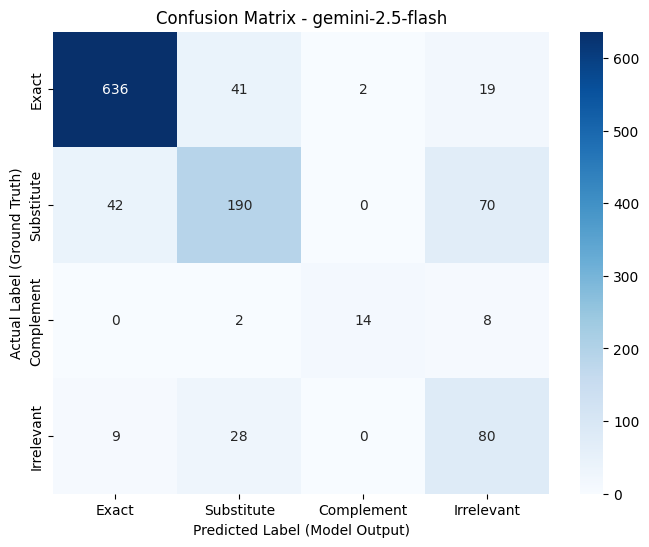

In [ ]:
print("Plotting base Model Results...")
plot_confusion_matrix(base_results)

In [ ]:
evaluate_by_query_segment(base_results)

Evaluation by Query Segment for Model: gemini-2.5-flash

>>> Query Segment: [ Head ]
--------------------------------------------------
Number of samples : 602
Accuracy          : 85.05%
Cohen's Kappa     : 0.7388 (Substantial)

Classification Report:
              precision    recall  f1-score   support

       Exact       0.97      0.96      0.97       380
  Substitute       0.76      0.66      0.71       142
  Complement       0.50      0.20      0.29         5
  Irrelevant       0.57      0.69      0.62        75

   micro avg       0.86      0.85      0.86       602
   macro avg       0.70      0.63      0.65       602
weighted avg       0.87      0.85      0.86       602

**************************************************

>>> Query Segment: [ Torso ]
--------------------------------------------------
Number of samples : 387
Accuracy          : 74.94%
Cohen's Kappa     : 0.5813 (Moderate)

Classification Report:
              precision    recall  f1-score   support

       Exact 

In [ ]:
base_errors = analyze_model_errors(
    base_results,
    output_csv_path="base_error_test data.csv",
    top_n=10
)


Error Analysis Report: gemini-2.5-flash
Total Errors Found: 240
--------------------------------------------------
Top 10 Most Severe Errors:


,agreement,description,product_name_local,language,result,search_query,query_segment,model_prediction,ground_truth,gt_score,pred_score,score_diff
369,100.0,"In a world full of stains and messes, you need...",Ariel Original All-in-1 Laundry Detergent Pods...,Arabic,Exact,شامبو غساله,Tail,Irrelevant,Exact,3,0,3
360,100.0,Description:\nGives your Abaya perfect cleanli...,Persil Black Abaya Shampoo 1 Ltr,Arabic,Exact,شامبو غساله,Tail,Irrelevant,Exact,3,0,3
361,100.0,1- Persil gel Sensitive is dermatologically te...,Persil Sensitive Gel Laundry Liquid Detergent ...,Arabic,Exact,شامبو غساله,Tail,Irrelevant,Exact,3,0,3
373,100.0,Hard water might leave limescale residues on y...,"Finish Dishwasher Salt, 2kg",Arabic,Exact,مسحوق فنش,Tail,Irrelevant,Exact,3,0,3
376,100.0,Maintain your dishwasher machine with Finish! ...,"Finish Dishwasher Cleaner, 250ml",Arabic,Exact,مسحوق فنش,Tail,Irrelevant,Exact,3,0,3
274,100.0,• A fun and unique way to enjoy the flavor of ...,"Vimto Candy Floss, 30g",Arabic,Exact,فيمتو,Head,Ir,Exact,3,0,3
188,100.0,The Hotpack Aluminium Pot set includes five 21...,Hotpack Aluminium Pot w/ Hood 21 cm 5 Pcs,Arabic,Exact,صحن,Head,Irrelevant,Exact,3,0,3
190,100.0,Introducing the Hotpack Aluminium Pot with Hoo...,Hotpack Aluminium Pot With Hood 34 cm x 5 Pcs,Arabic,Exact,صحن,Head,Irrelevant,Exact,3,0,3
531,100.0,Description:\n•GOLDEN AND CRISPY - Kellogg's C...,Kellogg's Honey & Nuts Corn Flakes 375 g,Arabic,Irrelevant,كورن,Torso,Exact,Irrelevant,0,3,3
523,100.0,Description:\n•Toasted golden flakes offer goo...,Kellogg's Corn Flakes 1 kg,Arabic,Irrelevant,كورن,Torso,Exact,Irrelevant,0,3,3


--------------------------------------------------
Full error report saved to: base_error_test data.csv


## Step7: Fine-tune the Model

 - `source_model`: Specifies the base Gemini model version you want to fine-tune.
 - `train_dataset`: Path to your training data in JSONL format.

  *Optional parameters*
 - `validation_dataset`: If provided, this data is used to evaluate the model during tuning.
 - `tuned_model_display_name`: Display name for the tuned model.
 - `epochs`: The number of training epochs to run.
 - `learning_rate_multiplier`: A value to scale the learning rate during training.
 - `adapter_size` : Gemini 2.5 Flash supports Adapter length [1, 2, 4, 8], default value is 4.

**Note: The default hyperparameter settings are optimized for optimal performance based on rigorous testing and are recommended for initial use. Users may customize these parameters to address specific performance requirements.**

In [ ]:
# 1. Set the model display name (You can modify this freely; avoid spaces or special characters)
tuned_model_display_name = "gemini-2.5-flash-new data-split 2 with misalignment"

In [ ]:
# 2. Set the training dataset path
training_dataset = {
    "gcs_uri": f"{bucket_path}{my_file_prefix}_train_samples.jsonl",
}

# 3. Set the validation dataset path
validation_dataset = types.TuningValidationDataset(
    gcs_uri=f"{bucket_path}{my_file_prefix}_val_samples.jsonl"
)

# 4. Start the fine-tuning job (This part remains unchanged; ensure base_model is defined in Step 4)
sft_tuning_job = client.tunings.tune(
    base_model=base_model,
    training_dataset=training_dataset,
    config=types.CreateTuningJobConfig(
        tuned_model_display_name=tuned_model_display_name,
        validation_dataset=validation_dataset,
        # You can add parameters like epochs or learning_rate_multiplier here
        # epochs=4,
        # learning_rate_multiplier=1.0
    ),
)

print(f"Tuning job started: {sft_tuning_job.name}")

/tmp/ipykernel_37282/1767759908.py:12: ExperimentalWarning: The SDK's tuning implementation is experimental, and may change in future versions.
  sft_tuning_job = client.tunings.tune(


Tuning job started: projects/462579788136/locations/us-central1/tuningJobs/8990981028734566400


In [ ]:
from google.genai import types

def create_tuning_job(client, base_model, bucket_path, display_name, file_prefix, epochs=None, learning_rate=None):
    """
    Wrapper function to launch a Gemini SFT fine-tuning job using the new SDK.
    """
    train_uri = f"{bucket_path}{file_prefix}_train_samples.jsonl"
    val_uri = f"{bucket_path}{file_prefix}_val_samples.jsonl"

    print(f"🚀 Starting tuning job for: {display_name}")
    print(f"📂 Training Data:   {train_uri}")
    print(f"📂 Validation Data: {val_uri}")

    tuning_config_args = {
        "tuned_model_display_name": display_name,
        "validation_dataset": {"gcs_uri": val_uri}
    }

    if epochs:
        tuning_config_args["epoch_count"] = epochs
    if learning_rate:
        tuning_config_args["learning_rate_multiplier"] = learning_rate

    job = client.tunings.tune(
        base_model=base_model,
        training_dataset={"gcs_uri": train_uri},
        config=types.CreateTuningJobConfig(**tuning_config_args),
    )

    print(f"✅ Job started! Name: {job.name}")
    return job

In [ ]:
tuning_job = client.tunings.get(name=sft_tuning_job.name)
tuning_job

TuningJob(
  base_model='gemini-2.5-flash',
  create_time=datetime.datetime(2026, 3, 25, 18, 28, 54, 347367, tzinfo=TzInfo(0)),
  name='projects/462579788136/locations/us-central1/tuningJobs/8990981028734566400',
  sdk_http_response=HttpResponse(
    headers=<dict len=9>
  ),
  start_time=datetime.datetime(2026, 3, 25, 18, 28, 54, 430794, tzinfo=TzInfo(0)),
  state=<JobState.JOB_STATE_RUNNING: 'JOB_STATE_RUNNING'>,
  supervised_tuning_spec=SupervisedTuningSpec(
    training_dataset_uri='gs://dh-search-science-shared/roman/qc-train-data/Thomas/Talabat-new-whole_dataset_train_samples.jsonl',
    validation_dataset_uri='gs://dh-search-science-shared/roman/qc-train-data/Thomas/Talabat-new-whole_dataset_val_samples.jsonl'
  ),
  tuned_model_display_name='gemini-2.5-flash-new data-split 2 with misalignment',
  update_time=datetime.datetime(2026, 3, 25, 18, 28, 55, 926647, tzinfo=TzInfo(0))
)

**Note: Tuning time depends on several factors, such as training data size, number of epochs, learning rate multiplier, etc.**

<div class="alert alert-block alert-warning">
<b>⚠️ It will take ~15 mins for the model tuning job to complete on the provided dataset and set configurations/hyperparameters. ⚠️</b>
</div>

### Status Check

In [ ]:
%%time
# Wait for job completion

running_states = [
    "JOB_STATE_PENDING",
    "JOB_STATE_RUNNING",
]

while tuning_job.state.name in running_states:
    print(".", end="")
    tuning_job = client.tunings.get(name=tuning_job.name)
    time.sleep(10)
print()

.........

.....................................................................................................................................................................................................
CPU times: user 2.51 s, sys: 307 ms, total: 2.82 s
Wall time: 39min 21s


In [ ]:
tuned_model = tuning_job.tuned_model.endpoint
experiment_name = tuning_job.experiment

print("Tuned model endpoint resource name:", tuned_model)
print("Tuned model experiment", experiment_name)

Tuned model endpoint resource name: projects/462579788136/locations/us-central1/endpoints/7588249262526300160
Tuned model experiment projects/462579788136/locations/us-central1/metadataStores/default/contexts/tuning-experiment-20260325113044883476


### Step7 [a]: Tuning and evaluation metrics

#### Model tuning metrics

- `/train_total_loss`: Loss for the tuning dataset at a training step.
- `/train_fraction_of_correct_next_step_preds`: The token accuracy at a training step. A single prediction consists of a sequence of tokens. This metric measures the accuracy of the predicted tokens when compared to the ground truth in the tuning dataset.
- `/train_num_predictions`: Number of predicted tokens at a training step

#### Model evaluation metrics:

- `/eval_total_loss`: Loss for the evaluation dataset at an evaluation step.
- `/eval_fraction_of_correct_next_step_preds`: The token accuracy at an evaluation step. A single prediction consists of a sequence of tokens. This metric measures the accuracy of the predicted tokens when compared to the ground truth in the evaluation dataset.
- `/eval_num_predictions`: Number of predicted tokens at an evaluation step.

The metrics visualizations are available after the model tuning job completes. If you don't specify a validation dataset when you create the tuning job, only the visualizations for the tuning metrics are available.


In [ ]:
# Locate Vertex AI Experiment and Vertex AI Experiment Run
experiment = aiplatform.Experiment(experiment_name=experiment_name)
filter_str = metadata_utils._make_filter_string(
    schema_title="system.ExperimentRun",
    parent_contexts=[experiment.resource_name],
)
experiment_run = context.Context.list(filter_str)[0]

In [ ]:
# Read data from Tensorboard
tensorboard_run_name = f"{experiment.get_backing_tensorboard_resource().resource_name}/experiments/{experiment.name}/runs/{experiment_run.name.replace(experiment.name, '')[1:]}"
tensorboard_run = aiplatform.TensorboardRun(tensorboard_run_name)
metrics = tensorboard_run.read_time_series_data()

In [ ]:
def get_metrics(metric: str = "/train_total_loss"):
    """Get metrics from Tensorboard.

    Args:
      metric: metric name, eg. /train_total_loss or /eval_total_loss.

    Returns:
      steps: list of steps.
      steps_loss: list of loss values.
    """
    loss_values = metrics[metric].values
    steps_loss = []
    steps = []
    for loss in loss_values:
        steps_loss.append(loss.scalar.value)
        steps.append(loss.step)
    return steps, steps_loss

In [ ]:
# Get Train and Eval Loss
train_loss = get_metrics(metric="/train_total_loss")
eval_loss = get_metrics(metric="/eval_total_loss")

### Step7 [b]: Plot the metrics

In [ ]:
# Plot the train and eval loss metrics using Plotly python library

fig = make_subplots(
    rows=1, cols=2, shared_xaxes=True, subplot_titles=("Train Loss", "Eval Loss")
)

# Add traces
fig.add_trace(
    go.Scatter(x=train_loss[0], y=train_loss[1], name="Train Loss", mode="lines"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=eval_loss[0], y=eval_loss[1], name="Eval Loss", mode="lines"),
    row=1,
    col=2,
)

# Add figure title
fig.update_layout(title="Train and Eval Loss", xaxis_title="Steps", yaxis_title="Loss")

# Set x-axis title
fig.update_xaxes(title_text="Steps")

# Set y-axes titles
fig.update_yaxes(title_text="Loss")

# Show plot
fig.show()

## Step8: Load the Tuned Model

 - Load the fine-tuned model using `GenerativeModel` class with the tuning job model endpoint name.

 - Test the tuned model with the following prompt

In [16]:
sft_endpoint_name = "projects/462579788136/locations/us-central1/endpoints/6176370779345649664"

In [17]:
sft_results = run_evaluation(
    test_df=test_df,
    model_name=sft_endpoint_name,
    prompt_template=PROMPT_TEMPLATE
)

Original data size: 1160
Cleaned data size:  1160
--------------------------------------------------
Starting Prediction with Model: projects/462579788136/locations/us-central1/endpoints/6176370779345649664


Predicting: 100%|██████████| 1160/1160 [31:59<00:00,  1.65s/it]


[Success] Results saved to CSV: evaluation_results.csv

Model: projects/462579788136/locations/us-central1/endpoints/6176370779345649664
Time: 1919.58s (1.6548s/sample)
Accuracy: 85.95%
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

       Exact       0.96      0.92      0.94       699
  Substitute       0.82      0.78      0.80       309
  Complement       0.91      0.84      0.88        25
  Irrelevant       0.60      0.75      0.66       127

   micro avg       0.87      0.86      0.86      1160
   macro avg       0.82      0.82      0.82      1160
weighted avg       0.88      0.86      0.87      1160

--------------------------------------------------
Cohen's Kappa Score: 0.7683 (Substantial)
--------------------------------------------------


Plotting SFT Model Results...


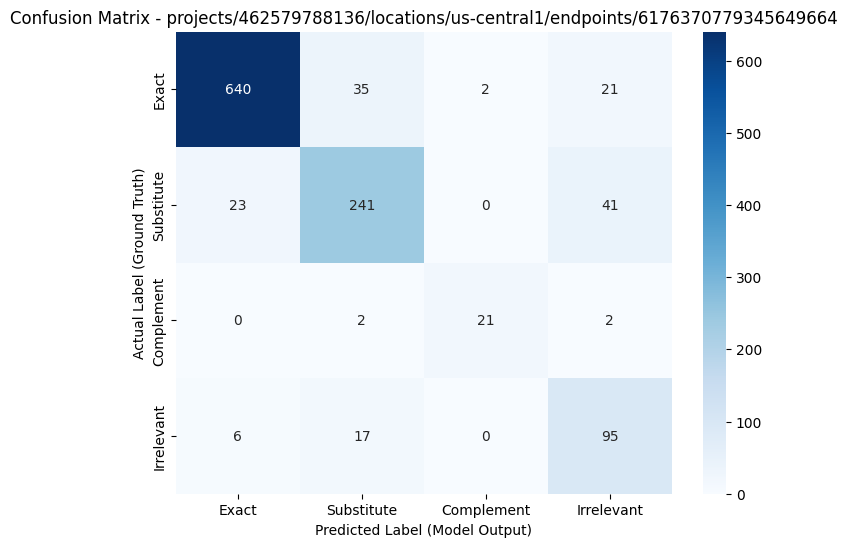

In [18]:
print("Plotting SFT Model Results...")
plot_confusion_matrix(sft_results)

In [19]:
sft_errors = analyze_model_errors(
    sft_results,
    output_csv_path="sft_errors_test data.csv",
    top_n=10
)


Error Analysis Report: projects/462579788136/locations/us-central1/endpoints/6176370779345649664
Total Errors Found: 163
--------------------------------------------------
Top 10 Most Severe Errors:


,agreement,description,product_name_local,language,result,search_query,query_segment,model_prediction,ground_truth,gt_score,pred_score,score_diff
176,100.0,Description:\n• Get your taste buds ready for ...,Lucky Me Regular Cup Chicken Mami Instant Nood...,Arabic,Irrelevant,شعيرية,Head,Exact,Irrelevant,0,3,3
177,100.0,Savor the taste of authentic Indonesian cuisin...,Mie Sedaap Goreng Fried Noodles 90 g,Arabic,Irrelevant,شعيرية,Head,Exact,Irrelevant,0,3,3
171,100.0,Indomie Special Fried Instant Noodles are a de...,"Indomie Special Fried Instant Noodles, 10x85g",Arabic,Irrelevant,شعيرية,Head,Exact,Irrelevant,0,3,3
173,100.0,• Pancit Canton. Flour Noodles,Hobe Pancit Canton 227 g,Arabic,Irrelevant,شعيرية,Head,Exact,Irrelevant,0,3,3
1025,100.0,• Earth's Finest Organic Apple Cider Vinegar i...,"Earth's Finest Organic Apple Cider Vinegar, 500ml",English,Exact,apple cider,Torso,Irrelevant,Exact,3,0,3
1026,100.0,Description:\nSourced from all natural apples....,Heinz Apple Cider Vinegar 473 ml,English,Exact,apple cider,Torso,Irrelevant,Exact,3,0,3
1027,100.0,Description:\nApple Cider Vinegar Is Unfiltere...,Heinz Apple Cider Vinegar 946 ml,English,Exact,apple cider,Torso,Irrelevant,Exact,3,0,3
1053,100.0,Lavazza Crema e Gusto is a coffee with a disti...,Lavazza Crema E Gusto Ground Coffee 250 g,English,Exact,crema,Torso,Irrelevant,Exact,3,0,3
467,100.0,Himalaya'S Oil Control Lemon Foaming Face Wash...,Himalaya Foaming Face Wash Oil Control Lemon 1...,Arabic,Exact,غسول,Torso,Ir,Exact,3,0,3
468,100.0,Clean & Clear's Daily Wash Exfoliating 150ml x...,Clean & Clear Daily Wash Exfoliating 150 ml x ...,Arabic,Exact,غسول,Torso,Irrelevant,Exact,3,0,3


--------------------------------------------------
Full error report saved to: sft_errors_test data.csv


In [20]:
evaluate_by_query_segment(sft_results)

Evaluation by Query Segment for Model: projects/462579788136/locations/us-central1/endpoints/6176370779345649664

>>> Query Segment: [ Head ]
--------------------------------------------------
Number of samples : 602
Accuracy          : 88.04%
Cohen's Kappa     : 0.7880 (Substantial)

Classification Report:
              precision    recall  f1-score   support

       Exact       0.97      0.96      0.96       380
  Substitute       0.84      0.73      0.78       142
  Complement       0.75      0.60      0.67         5
  Irrelevant       0.63      0.77      0.69        75

   micro avg       0.89      0.88      0.88       602
   macro avg       0.80      0.77      0.78       602
weighted avg       0.89      0.88      0.88       602

**************************************************

>>> Query Segment: [ Torso ]
--------------------------------------------------
Number of samples : 387
Accuracy          : 83.98%
Cohen's Kappa     : 0.7573 (Substantial)

Classification Report:
        

##Step9:DPO preparation

In [ ]:
# ==========================================
# 1. Prepare Data and Model
# ==========================================

# Attempt to read the training dataset CSV generated in Step 3
try:
    # Ensure we are reading the training set (as we want to find Hard Cases the model couldn't learn)
    train_data_df = pd.read_csv("experiment_en_train_samples")
    print(f"✅ Successfully loaded training dataset: {len(train_data_df)} records")
except FileNotFoundError:
    print("⚠️ Could not find 'experiment_en_train_samples'. Please confirm if Step 3 has been executed.")
    # If the variable is still in memory, we can use train_df directly
    if 'train_df' in locals():
        train_data_df = train_df
        print(f"✅ Directly using train_df from memory: {len(train_data_df)} records")

# Set your SFT Model Endpoint (Please confirm this is the Endpoint trained in Step 8)
# This is the Endpoint found from your provided Log; please verify based on your actual situation
sft_endpoint_name = "projects/462579788136/locations/us-central1/endpoints/8345274563122167808"

# ==========================================
# 2. Run Evaluation (Run Evaluation on Train Data)
# ==========================================
print("\n" + "="*50)
print("🚀 Starting prediction on Training Data (Searching for DPO candidate samples)...")
print("="*50)

# Use your defined function to run prediction
train_results = run_evaluation(
    test_df=train_data_df,       # Pass in training data here
    model_name=sft_endpoint_name, # Use the model after SFT
    prompt_template=PROMPT_TEMPLATE
)

# ==========================================
# 3. Visualize Results (Confusion Matrix)
# ==========================================
print("\n📊 Plotting Confusion Matrix...")
plot_confusion_matrix(train_results)

# ==========================================
# 4. Error Analysis and DPO Data Export (Analyze Errors)
# ==========================================
print("\n🔍 Analyzing errors and exporting DPO candidate data...")

# This will find all cases where model_prediction != ground_truth
# These are the best materials for DPO:
#   - Prompt: search_query + product_name
#   - Chosen (Win): ground_truth
#   - Rejected (Loss): model_prediction (because this is what the model got wrong)

dpo_candidates_df = analyze_model_errors(
    results_dict=train_results,
    output_csv_path="dpo_candidates_from_train.csv", # Filename for saving
    top_n=10 # Show top 10 severe errors
)

print(f"\n✅ DPO preparation complete! Found {len(dpo_candidates_df)} error samples in total.")
print("You can use 'dpo_candidates_from_train.csv' to create the JSONL file for Preference Tuning.")

In [ ]:
import pandas as pd
import os

# Define the filename
csv_filename = "sft_error_before dpo_train data.csv"

# Check if file exists before loading
if os.path.exists(csv_filename):
    # 1. Load the CSV
    df = pd.read_csv(csv_filename)

    # 2. Filter for rows where 'T/F' is 'T'
    # We strip whitespace just in case there are hidden spaces
    df_filtered = df[df['T/F'].astype(str).str.strip() == 'T'].copy()

    print(f"✅ CSV loaded successfully.")
    print(f"Total rows in original file: {len(df)}")
    print(f"Rows selected for training (T/F = T): {len(df_filtered)}")

    # Display the first few rows to verify columns
    print("\nSample of filtered data:")
    display(df_filtered.head(3))

else:
    print(f"❌ Error: Could not find file '{csv_filename}'. Please ensure it is uploaded to the Colab runtime.")

In [ ]:
import json
import pandas as pd

def generate_gemini_dpo_dataset(input_df, prompt_template, output_filename):
    """
    Transforms a DataFrame into Gemini Preference Tuning (DPO) JSONL format.

    Parameters:
    1. input_df (pd.DataFrame): Data containing 'search_query', 'product_name_local', 'result', 'model_prediction'.
    2. prompt_template (str): A string with '{query}' and '{product}' placeholders.
    3. output_filename (str): The path to save the JSONL file.

    Returns:
    list: The list of dictionary objects generated.
    """

    dpo_dataset = []
    print("🔄 Transforming data...")

    for index, row in input_df.iterrows():
        try:
            # 1. Prepare dynamic variables
            query_val = str(row['search_query'])
            product_val = str(row['product_name_local'])

            # 2. Fill the prompt template
            user_prompt = prompt_template.format(query=query_val, product=product_val)

            # 3. Get the Chosen (Ground Truth) and Rejected (Model Error)
            chosen_text = str(row['result'])
            rejected_text = str(row['model_prediction'])

            # 4. Build the Gemini DPO dictionary object
            entry = {
                "contents": [
                    {
                        "role": "user",
                        "parts": [{"text": user_prompt}]
                    }
                ],
                "completions": [
                    # Chosen response (Score 1.0)
                    {
                        "score": 1.0,
                        "completion": {
                            "role": "model",
                            "parts": [{"text": chosen_text}]
                        }
                    },
                    # Rejected response (Score 0.0)
                    {
                        "score": 0.0,
                        "completion": {
                            "role": "model",
                            "parts": [{"text": rejected_text}]
                        }
                    }
                ]
            }
            dpo_dataset.append(entry)

        except KeyError as e:
            print(f"Skipping row {index}: Missing column {e}")
        except Exception as e:
            print(f"Error at index {index}: {e}")

    # 5. Save to JSONL file
    if dpo_dataset:
        with open(output_filename, 'w', encoding='utf-8') as f:
            for entry in dpo_dataset:
                f.write(json.dumps(entry) + '\n')

        print(f"✅ Transformation complete!")
        print(f"Saved {len(dpo_dataset)} examples to '{output_filename}'")

        # 6. Output the first line for verification (Requirement #4)
        print("\n🔍 Preview of the first JSONL entry:")
        print(json.dumps(dpo_dataset[0], indent=2))
    else:
        print("⚠️ No data was transformed. Please check your input DataFrame.")

    return dpo_dataset

In [ ]:
DPO_TEMPLATE = """You are a search relevance expert. Your task is to label ecommerce products relevance for a given query.
Output ONLY the single word label.

Query: {query}
Product: {product}
Result:"""

dpo_data = generate_gemini_dpo_dataset(
    input_df=df_filtered,
    prompt_template=DPO_TEMPLATE,
    output_filename="gemini_dpo_training_data.jsonl"
)

In [ ]:
import json
import random
import os

def prepare_and_upload_to_gcs(data_list, gcs_bucket_path, val_ratio=0.15, random_seed=42):
    """
    Splits the data into training and validation sets, saves them locally,
    and uploads them to Google Cloud Storage.

    Parameters:
    1. data_list (list): The list of DPO data dictionaries (from the previous step).
    2. gcs_bucket_path (str): The GCS folder path (e.g., "gs://my-bucket/folder").
    3. val_ratio (float): The proportion of data to use for validation (default 0.15).
    4. random_seed (int): Seed for reproducibility.

    Returns:
    tuple: (train_gcs_uri, val_gcs_uri) if successful, else (None, None).
    """

    # 1. Validation Check
    if not data_list:
        print("❌ Error: Input data_list is empty.")
        return None, None

    total_count = len(data_list)
    print(f"Total data points: {total_count}")

    # ==========================================
    # 2. Perform Split (Train / Val)
    # ==========================================
    # Shuffle data order
    random.seed(random_seed)
    # Create a copy to avoid modifying the original list outside the function
    shuffled_data = data_list.copy()
    random.shuffle(shuffled_data)

    # Calculate validation set size
    val_count = int(total_count * val_ratio)

    # Safety check: Ensure at least 1 validation item, and training data is not empty
    if val_count < 1 and total_count > 1:
        val_count = 1
    elif val_count >= total_count:
        val_count = total_count - 1 # Keep at least one item for training

    # Split the lists
    val_data = shuffled_data[:val_count]
    train_data = shuffled_data[val_count:]

    print("-" * 30)
    print(f"Split Strategy: {int(val_ratio*100)}% Validation")
    print(f"Training set size:   {len(train_data)}")
    print(f"Validation set size: {len(val_data)}")
    print("-" * 30)

    # ==========================================
    # 3. Save as temporary local JSONL files
    # ==========================================
    # We still need to save files locally because `gsutil` uploads from file system
    train_filename = "train_data.jsonl"
    val_filename = "val_data.jsonl"

    def save_jsonl(filename, content):
        with open(filename, 'w', encoding='utf-8') as f:
            for entry in content:
                f.write(json.dumps(entry, ensure_ascii=False) + '\n')
        print(f"Saved local file: {filename}")

    save_jsonl(train_filename, train_data)
    save_jsonl(val_filename, val_data)

    # ==========================================
    # 4. Upload to Google Cloud Storage
    # ==========================================
    print(f"\n📤 Uploading files to: {gcs_bucket_path} ...")

    # Remove trailing slash from path if present to avoid double slashes
    gcs_bucket_path = gcs_bucket_path.rstrip('/')

    # Use os.system to execute gsutil commands
    ret_train = os.system(f"gsutil cp {train_filename} {gcs_bucket_path}/{train_filename}")
    ret_val = os.system(f"gsutil cp {val_filename} {gcs_bucket_path}/{val_filename}")

    if ret_train == 0 and ret_val == 0:
        train_uri = f"{gcs_bucket_path}/{train_filename}"
        val_uri = f"{gcs_bucket_path}/{val_filename}"

        print("\n✅ Upload successful! Use these URIs for training:")
        print(f"Training data:   {train_uri}")
        print(f"Validation data: {val_uri}")

        return train_uri, val_uri
    else:
        print("\n❌ Upload failed. Please check your GCS path and permissions.")
        return None, None

In [ ]:
train_uri, val_uri = prepare_and_upload_to_gcs(
    data_list=dpo_data,
    gcs_bucket_path=bucket_path
)

if train_uri:
    print(f"Ready to train with: {train_uri}")

In [ ]:
from google.genai import types
SFT_MODEL_URI = "projects/462579788136/locations/us-central1/models/1047921442689122304"

# Hyperparameters
EPOCHS = 3
LEARNING_RATE = 1.0
ADAPTER_SIZE = "ADAPTER_SIZE_FOUR"
BETA = 0.1

print(f"Base Model: {SFT_MODEL_URI}")
print(f"Epochs: {EPOCHS}")
print(f"Adapter Size: {ADAPTER_SIZE}")
print(f"Beta: {BETA}")

In [ ]:
from google.genai import types

def submit_dpo_tuning_job(client, base_model_uri, train_uri, val_uri,
                          display_name="gemini-dpo-tuning-v1",
                          epochs=4, adapter_size=4, learning_rate=1.0, beta=0.1,
                          project_id="462579788136", location="us-central1"):
    """
    Submits a Gemini Preference Tuning (DPO) job to Vertex AI (Fixed for SDK v1.0+).
    """

    print(f"🚀 Submitting tuning job: {display_name} ...\n")

    # ==========================================
    # 1. Fix Adapter Size (Int -> Enum String)
    # ==========================================
    # Map integer input to the required API Enum string
    adapter_size_map = {
        1: "ADAPTER_SIZE_ONE",
        4: "ADAPTER_SIZE_FOUR",
        8: "ADAPTER_SIZE_EIGHT",
        16: "ADAPTER_SIZE_SIXTEEN"
    }

    # Get the string value, default to 4 if not found
    final_adapter_size = adapter_size_map.get(adapter_size, "ADAPTER_SIZE_FOUR")
    print(f"   Using Adapter Size: {final_adapter_size} (mapped from {adapter_size})")

    try:
        # ==========================================
        # 2. Fix Dataset Types
        # ==========================================
        # Training uses TuningDataset
        training_dataset = types.TuningDataset(
            gcs_uri=train_uri
        )

        # Validation MUST use TuningValidationDataset (Fixing the Type Mismatch warning)
        validation_dataset = types.TuningValidationDataset(
            gcs_uri=val_uri
        )

        # ==========================================
        # 3. Submit the tuning job
        # ==========================================
        tuning_job = client.tunings.tune(
            base_model=base_model_uri,
            training_dataset=training_dataset,
            config=types.CreateTuningJobConfig(
                tuned_model_display_name=display_name,
                method="PREFERENCE_TUNING",
                epoch_count=epochs,
                adapter_size=final_adapter_size,  # ✅ Passing string now
                learning_rate_multiplier=learning_rate,
                beta=beta,
                validation_dataset=validation_dataset, # ✅ Passing correct type
            ),
        )

        # 4. Get job information
        job_name = tuning_job.name
        job_id = job_name.split("/")[-1] if "/" in job_name else job_name

        print("✅ Tuning job submitted successfully!\n")
        print(f"Job Name: {job_name}")
        print(f"Job ID:   {job_id}\n")

        # 5. Generate Monitoring Link
        if project_id:
            monitor_url = f"https://console.cloud.google.com/vertex-ai/tuning/locations/{location}/tuningJob/{job_id}/monitor?project={project_id}"
            print("Monitor progress in the console:")
            print(monitor_url)

        print("\n⏱️ Training will take approximately 30-60 minutes.")

        return tuning_job

    except Exception as e:
        print(f"❌ Error submitting job: {e}")
        # Print detailed error if available
        if hasattr(e, 'details'):
            print(f"Details: {e.details()}")
        return None

In [ ]:
dpo_job = submit_dpo_tuning_job(
    client=client,
    base_model_uri=SFT_MODEL_URI,
    train_uri=train_uri,
    val_uri=val_uri,
    display_name="en-gemini-dpo-experiment-01",
    project_id="462579788136"
)

In [ ]:
# Step 6: Check tuning job status
import time

# ✅ I have automatically filled in the job name generated from the previous step
JOB_NAME = "projects/462579788136/locations/us-central1/tuningJobs/2401672508500606976"

if not JOB_NAME or JOB_NAME == "[your_job_name]":
    print("⚠️ Please set JOB_NAME above with the value from Step 5")
else:
    try:
        # Query the current job status from Vertex AI
        tuning_job = client.tunings.get(name=JOB_NAME)
        state = tuning_job.state

        print(f"📊 Current Status: {state}\n")

        # Provide feedback based on the status
        if state == "JOB_STATE_PENDING":
            print("⏳ Job is queued, waiting for compute resources...")
            print("   (Queued: Waiting for Google to allocate resources. This usually takes 2-5 minutes.)")
            print("   Please re-run this cell in a few minutes to check again.")

        elif state == "JOB_STATE_RUNNING":
            print("🔄 Training is in progress!")
            print("   (Training: The model is learning from your data.)")
            print("   This typically takes 30-60 minutes. Feel free to take a break and check back later.")

        elif state == "JOB_STATE_SUCCEEDED":
            print("✅ Training completed successfully!\n")
            print("🎯 Your tuned model is ready to use!")
            print("   (Training complete! You can proceed to Step 7 to test the model.)")

            # Display model information
            if hasattr(tuning_job, "tuned_model") and tuning_job.tuned_model:
                if hasattr(tuning_job.tuned_model, "endpoint"):
                    print(f"📝 Endpoint: {tuning_job.tuned_model.endpoint}")

        elif state == "JOB_STATE_FAILED":
            print("❌ Training failed.\n")
            if hasattr(tuning_job, "error"):
                print("Error details:")
                print(tuning_job.error)

        else:
            print(f"❓ Unknown state: {state}")

    except Exception as e:
        print(f"❌ Error checking job status: {e}")

Test again

In [ ]:
DPO_tuned_model = "projects/462579788136/locations/us-central1/endpoints/6013958068516159488"

en_DPO_results = run_evaluation(
    test_df=test_df,
    model_name=DPO_tuned_model,
    prompt_template=PROMPT_TEMPLATE
)

In [ ]:
print("Plotting DPO+SFT Model Results...")
plot_confusion_matrix(en_DPO_results)

In [ ]:
sft_errors = analyze_model_errors(
    en_DPO_results,
    output_csv_path="sft_error_after dpo_test data.csv",
    top_n=10
)

In [ ]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

# 1. Define Data
n1 = 1192
p1 = 0.9237
n2 = 1192
p2 = 0.9169

# Calculate number of successes (Required as integers for the test)
count1 = round(p1 * n1)
count2 = round(p2 * n2)

print(f"Pre-tuning successes: {count1}, Sample size: {n1}")
print(f"Post-tuning successes: {count2}, Sample size: {n2}")
print("-" * 35)

# --- Method 1: Using statsmodels (Recommended) ---
# 'larger' means we are testing if the proportion in the first array (Post)
# is greater than the second array (Pre).
counts = np.array([count2, count1])  # Order: [Post-tuning, Pre-tuning]
nobs = np.array([n2, n1])
z_stat, p_val = proportions_ztest(counts, nobs, alternative='larger')

print("[Method 1: statsmodels Results]")
print(f"Z-score: {z_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# --- Conclusion ---
alpha = 0.05
print("-" * 35)
if p_val < alpha:
    print(f"Conclusion: P-value < {alpha}. Result is statistically significant!")
    print("The fine-tuned model is significantly better.")
else:
    print(f"Conclusion: P-value > {alpha}. Result is NOT statistically significant.")
    print("The improvement may be due to random chance.")